# Sales Prediction using Python

## CodeAlpha Data Science Internship

### Objective
Predict future sales using advertising and related features with regression techniques.

### Workflow
1. Import Libraries
2. Load Dataset
3. Data Preprocessing
4. Exploratory Data Analysis
5. Feature Engineering
6. Train/Test Split
7. Model Training
8. Model Evaluation
9. Prediction
10. Conclusion


# Sales Prediction using Python

### CodeAlpha Data Science Internship

**Objective:**
The objective of this project is to build a machine learning regression model to predict product sales based on advertising expenditure across TV, Radio, and Newspaper media.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

## Dataset Loading

In [2]:
df = pd.read_csv("Advertising.csv")

df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


## Dataset Information

In [3]:
df.shape

(200, 5)

In [4]:
df.columns

Index(['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales'], dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [6]:
df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [7]:
df.isnull().sum()

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.drop("Unnamed: 0", axis=1, inplace=True)

df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


## Exploratory Data Analysis

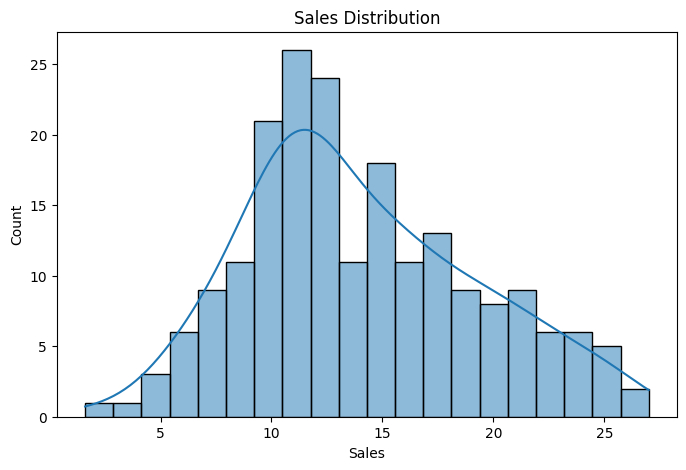

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(df["Sales"], bins=20, kde=True)

plt.title("Sales Distribution")

plt.show()

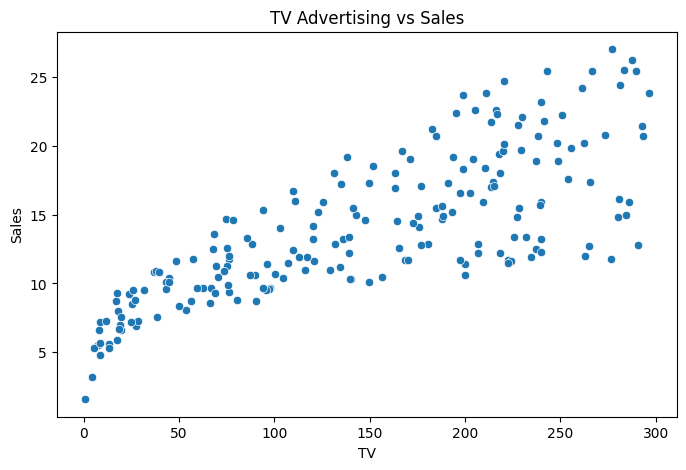

In [11]:
plt.figure(figsize=(8,5))

sns.scatterplot(x="TV", y="Sales", data=df)

plt.title("TV Advertising vs Sales")

plt.show()

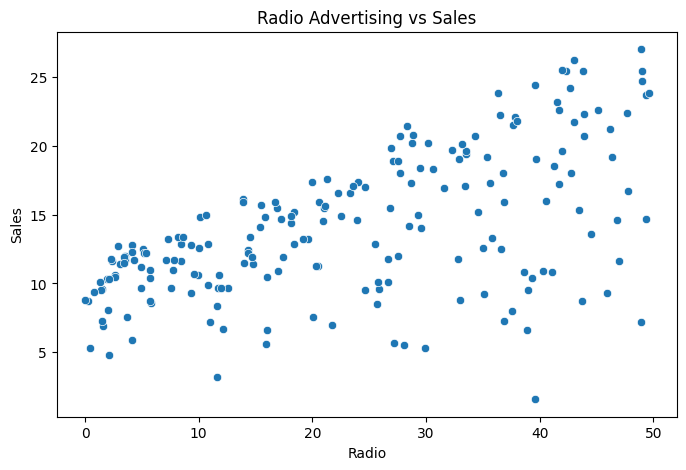

In [12]:
plt.figure(figsize=(8,5))

sns.scatterplot(x="Radio", y="Sales", data=df)

plt.title("Radio Advertising vs Sales")

plt.show()

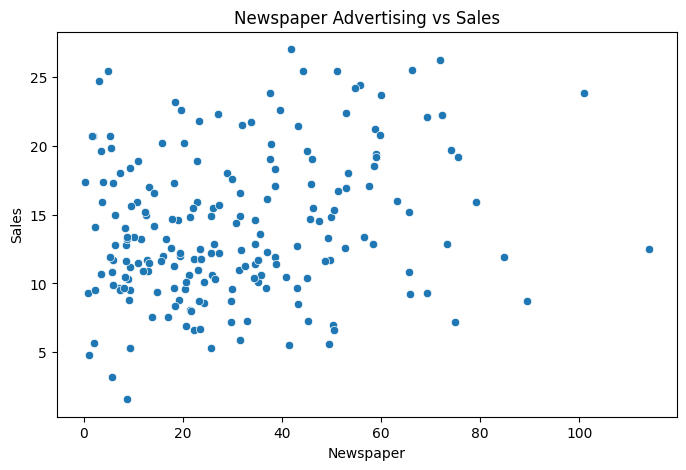

In [13]:
plt.figure(figsize=(8,5))

sns.scatterplot(x="Newspaper", y="Sales", data=df)

plt.title("Newspaper Advertising vs Sales")

plt.show()

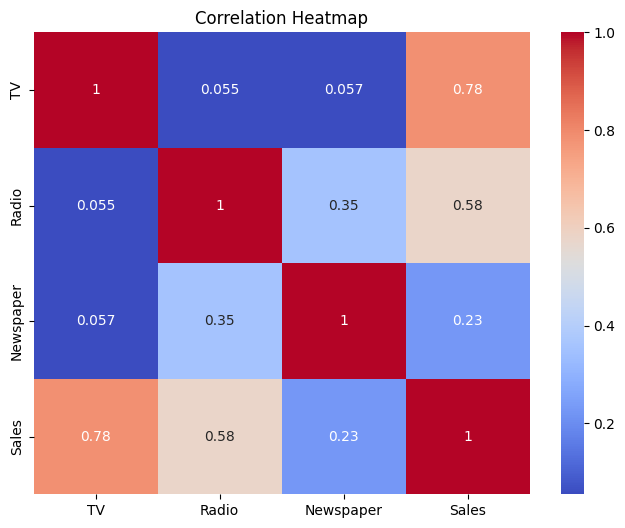

In [14]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

## Data Preprocessing

In [15]:
X = df.drop("Sales", axis=1)

y = df["Sales"]

## Feature Selection and Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

## Model Training

In [17]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [18]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [19]:
rf = RandomForestRegressor(
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

## Model Evaluation

In [20]:
def evaluate(model_name, y_test, y_pred):

    print("="*40)
    print(model_name)
    print("="*40)

    print("MAE :", mean_absolute_error(y_test,y_pred))
    print("MSE :", mean_squared_error(y_test,y_pred))
    print("RMSE :", np.sqrt(mean_squared_error(y_test,y_pred)))
    print("R2 Score :", r2_score(y_test,y_pred))

In [21]:
evaluate("Linear Regression", y_test, lr_pred)

evaluate("Decision Tree", y_test, dt_pred)

evaluate("Random Forest", y_test, rf_pred)

Linear Regression
MAE : 1.4607567168117606
MSE : 3.174097353976106
RMSE : 1.7815996615334506
R2 Score : 0.8994380241009119
Decision Tree
MAE : 0.9850000000000001
MSE : 2.175
RMSE : 1.4747881203752624
R2 Score : 0.9310914968293178
Random Forest
MAE : 0.6200999999999988
MSE : 0.5907322499999988
RMSE : 0.7685910811348248
R2 Score : 0.9812843792541843


In [22]:
results = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "R2 Score":[
        r2_score(y_test,lr_pred),
        r2_score(y_test,dt_pred),
        r2_score(y_test,rf_pred)
    ]

})

results

,Model,R2 Score
0,Linear Regression,0.899438
1,Decision Tree,0.931091
2,Random Forest,0.981284


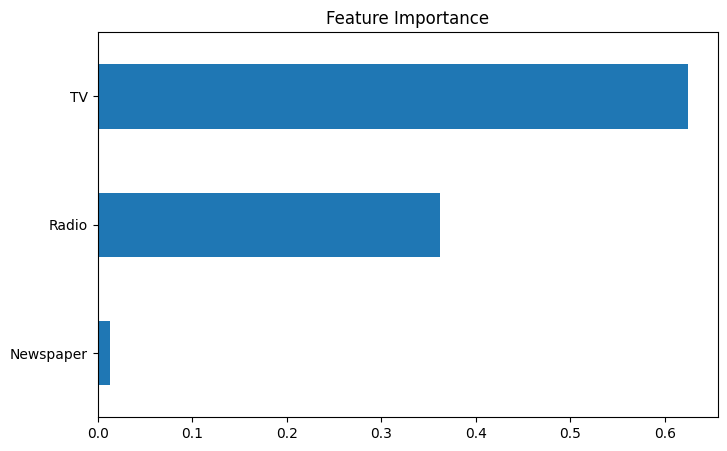

In [23]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Feature Importance")

plt.show()

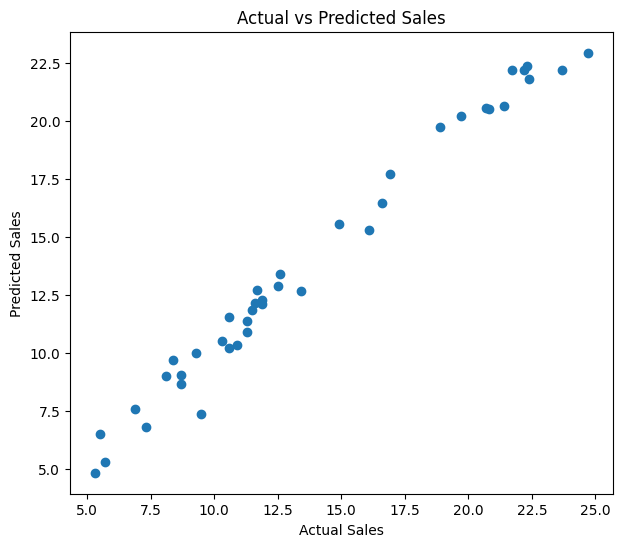

In [24]:
plt.figure(figsize=(7,6))

plt.scatter(y_test, rf_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()

## Conclusion

- Successfully built a machine learning regression model to predict product sales.
- Performed data cleaning, feature selection, and model evaluation.
- Compared Linear Regression, Decision Tree, and Random Forest models.
- Random Forest Regressor achieved the best prediction accuracy.
- The analysis showed that TV and Radio advertising have a greater impact on sales than Newspaper advertising.
- These insights can help businesses optimize advertising budgets and improve marketing strategies.

# Conclusion

This notebook demonstrates an end-to-end machine learning workflow including preprocessing, visualization, model training, evaluation, and prediction. The project is organized for CodeAlpha internship submission with clear documentation and reproducible steps.
